# Instructional Notebook for SHRED + Biomechanics

The following lines can be uncommented if running this notebook in Google Colab. Uncomment by highlighting lines and pressing Ctrl+/

In [23]:
#from google.colab import drive
#drive.mount('/content/drive')
#!pip install mat73
#!git clone https://github.com/Jan-Williams/pyshred
#%cd /content/pyshred

These lines import standard packages for managing data.

In [24]:
import os
import numpy as np
import altair as alt
import pandas as pd
from processdata import TimeSeriesDataset
import models_TCN
import torch
from sklearn.preprocessing import MinMaxScaler
from scipy.io import loadmat
import mat73
import functions as ft
from pathlib import Path

In [25]:
cwd = os.getcwd()
main_path = os.path.dirname(cwd) + '/Dataset_Stroke' 
print(main_path)

/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke


In [26]:

dataset_path = main_path+'/Yan_Stroke Experiment Data' # sets path to dataset / raw data
dataframe_path = main_path+'/Dataframes'  # file path for saved dataframe results of test data
figure_path = main_path+'/Figures'
model_path = main_path+'/Models' # optionally, save the models that are trained
print(dataset_path)
print(dataframe_path)


/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data
/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Dataframes


The example dataset contains several activities, two of which are 'Walking' and 'Running'. Access each independently.

In [28]:
#df_tmp = pd.DataFrame(data=df['Walking']['APDM_Accel']['Data'],
#                      columns = df['Walking']['APDM_Accel']['Labels'])

df_tmp = pd.read_csv('/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/Processed_Gait_Data_Full.csv')

pd.set_option('display.max_columns', None)

df_tmp.head(5) # check that correct data was selected

,datetime,epoc (ms),timestamp,elapsed (s),S1_acc_x,S1_acc_y,S1_acc_z,S1_gyro_x,S1_gyro_y,S1_gyro_z,S2_acc_x,S2_acc_y,S2_acc_z,S2_gyro_x,S2_gyro_y,S2_gyro_z,S3_acc_x,S3_acc_y,S3_acc_z,S3_gyro_x,S3_gyro_y,S3_gyro_z,S4_acc_x,S4_acc_y,S4_acc_z,S4_gyro_x,S4_gyro_y,S4_gyro_z,S5_acc_x,S5_acc_y,S5_acc_z,S5_gyro_x,S5_gyro_y,S5_gyro_z,S6_acc_x,S6_acc_y,S6_acc_z,S6_gyro_x,S6_gyro_y,S6_gyro_z,S1_acc_x_filtered,S1_acc_y_filtered,S1_acc_z_filtered,S1_gyro_x_filtered,S1_gyro_y_filtered,S1_gyro_z_filtered,S2_acc_x_filtered,S2_acc_y_filtered,S2_acc_z_filtered,S2_gyro_x_filtered,S2_gyro_y_filtered,S2_gyro_z_filtered,S3_acc_x_filtered,S3_acc_y_filtered,S3_acc_z_filtered,S3_gyro_x_filtered,S3_gyro_y_filtered,S3_gyro_z_filtered,S4_acc_x_filtered,S4_acc_y_filtered,S4_acc_z_filtered,S4_gyro_x_filtered,S4_gyro_y_filtered,S4_gyro_z_filtered,S5_acc_x_filtered,S5_acc_y_filtered,S5_acc_z_filtered,S5_gyro_x_filtered,S5_gyro_y_filtered,S5_gyro_z_filtered,S6_acc_x_filtered,S6_acc_y_filtered,S6_acc_z_filtered,S6_gyro_x_filtered,S6_gyro_y_filtered,S6_gyro_z_filtered,S1_pitch,S6_pitch
0,2024-03-16 04:40:45.018,1710564045018,2024-03-16T04.40.45.018,0.00,0.322,1.318,-0.086,2.134,-9.841,-6.805,-0.204,0.978,-0.063,-20.508,-5.020,1.037,0.055,0.959,-0.095,-6.482,10.408,-10.744,-0.539,0.432,0.880,36.789,-25.020,3.537,-0.461,0.060,0.960,8.829,2.622,3.707,-0.070,0.290,0.951,-0.214,0.000,-0.762,0.321978,1.317996,-0.085985,2.132829,-9.848289,-6.803849,-0.204004,0.977992,-0.062984,-20.508020,-5.021110,1.036969,0.054991,0.959017,-0.094981,-6.484595,10.412430,-10.743842,-0.539007,0.432027,0.880009,36.787646,-25.017837,3.527622,-0.461001,0.060009,0.959997,8.828262,2.622283,3.706550,-0.069999,0.289999,0.950998,-0.213963,-0.000028,-0.761994,13.700108,-4.027293
1,2024-03-16 04:40:45.028,1710564045028,2024-03-16T04.40.45.028,0.01,0.334,1.070,-0.008,-9.549,13.463,-2.951,-0.234,0.976,-0.042,-18.736,-6.341,0.022,0.050,0.952,-0.091,-4.433,11.244,-10.659,-0.243,0.026,0.846,13.805,1.195,3.512,-0.456,0.053,0.965,7.967,2.378,3.659,-0.070,0.288,0.948,-0.244,-0.061,-0.732,0.138566,1.103058,-0.100079,-5.448346,7.812697,-5.092843,-0.207770,0.974593,-0.041272,-18.604886,-6.347820,0.157790,0.045698,0.954396,-0.091409,-4.281141,10.475916,-10.212477,-0.454350,0.152919,0.904803,23.612979,-6.061669,-2.938470,-0.459698,0.057952,0.963011,7.518801,2.616948,3.251222,-0.070124,0.288533,0.950537,-0.333838,-0.001357,-0.678390,7.130985,-4.037962
2,2024-03-16 04:40:45.038,1710564045038,2024-03-16T04.40.45.038,0.02,-0.065,0.860,-0.117,-16.057,30.203,-4.614,-0.206,0.970,-0.022,-16.667,-8.130,-0.569,0.040,0.953,-0.088,-2.805,10.488,-9.756,-0.649,-0.108,0.958,7.061,27.609,-19.170,-0.459,0.056,0.967,6.323,2.695,2.750,-0.071,0.287,0.950,-0.495,0.007,-0.603,-0.011431,0.956908,-0.113454,-9.932563,17.876552,-3.990307,-0.209173,0.971613,-0.023737,-16.627018,-7.050567,-0.624237,0.036715,0.955156,-0.085201,-2.432907,10.329887,-9.626483,-0.386207,-0.033366,0.936408,13.378704,6.528739,-8.652262,-0.459224,0.057061,0.964880,6.250845,2.526798,2.787136,-0.070199,0.287595,0.950364,-0.431298,-0.002419,-0.614404,-0.679626,-4.044008
3,2024-03-16 04:40:45.048,1710564045048,2024-03-16T04.40.45.048,0.03,-0.201,0.939,-0.173,-7.304,13.695,-4.719,-0.196,0.969,-0.013,-14.439,-6.500,-1.244,0.027,0.961,-0.079,-0.951,10.098,-8.805,-0.289,-0.051,0.974,13.658,-6.085,-9.098,-0.462,0.062,0.963,4.854,2.335,2.055,-0.070,0.288,0.952,-0.549,0.024,-0.549,-0.098539,0.911192,-0.122767,-10.191132,17.325861,-3.778829,-0.208078,0.969331,-0.012900,-14.533752,-6.841777,-1.255419,0.029033,0.963717,-0.075757,-1.232202,9.968509,-8.997483,-0.351853,-0.088267,0.974330,6.885250,10.695632,-13.307577,-0.459810,0.057757,0.965193,5.088175,2.294311,2.321336,-0.070247,0.287419,0.950470,-0.493503,-0.004644,-0.583105,-6.117273,-4.046592
4,2024-03-16 04:40:45.058,1710564045058,2024-03-16T04.40.45.058,0.04,-0.074,1.010,-0.155,-2.000,-1.463,-3.488,-0.207,0.969,-0.007,-12.383,-5.460,-1.812,0.021,0.981,-0.066,-0.765,8.941,-8.182,-0.281,0.014,1.016,7.059,2.676,-14.485,-0.

### Simplify dataframe

In [30]:
# trim length of trial (number of rows in df)
frequency=100
obs_samples_trial = 8*60*frequency
df_2 = df_tmp.tail(obs_samples_trial) # keep last n samples to exclude speed transitions

# downsample trial
obs_samples_freq = int(100/frequency)

df_2 = df_2.iloc[::obs_samples_freq,:]
df_2

,datetime,epoc (ms),timestamp,elapsed (s),S1_acc_x,S1_acc_y,S1_acc_z,S1_gyro_x,S1_gyro_y,S1_gyro_z,S2_acc_x,S2_acc_y,S2_acc_z,S2_gyro_x,S2_gyro_y,S2_gyro_z,S3_acc_x,S3_acc_y,S3_acc_z,S3_gyro_x,S3_gyro_y,S3_gyro_z,S4_acc_x,S4_acc_y,S4_acc_z,S4_gyro_x,S4_gyro_y,S4_gyro_z,S5_acc_x,S5_acc_y,S5_acc_z,S5_gyro_x,S5_gyro_y,S5_gyro_z,S6_acc_x,S6_acc_y,S6_acc_z,S6_gyro_x,S6_gyro_y,S6_gyro_z,S1_acc_x_filtered,S1_acc_y_filtered,S1_acc_z_filtered,S1_gyro_x_filtered,S1_gyro_y_filtered,S1_gyro_z_filtered,S2_acc_x_filtered,S2_acc_y_filtered,S2_acc_z_filtered,S2_gyro_x_filtered,S2_gyro_y_filtered,S2_gyro_z_filtered,S3_acc_x_filtered,S3_acc_y_filtered,S3_acc_z_filtered,S3_gyro_x_filtered,S3_gyro_y_filtered,S3_gyro_z_filtered,S4_acc_x_filtered,S4_acc_y_filtered,S4_acc_z_filtered,S4_gyro_x_filtered,S4_gyro_y_filtered,S4_gyro_z_filtered,S5_acc_x_filtered,S5_acc_y_filtered,S5_acc_z_filtered,S5_gyro_x_filtered,S5_gyro_y_filtered,S5_gyro_z_filtered,S6_acc_x_filtered,S6_acc_y_filtered,S6_acc_z_filtered,S6_gyro_x_filtered,S6_gyro_y_filtered,S6_gyro_z_filtered,S1_pitch,S6_pitch
6452,2024-03-16 04:41:49.538,1710564109538,2024-03-16T04.41.49.538,64.52,0.159,1.210,-0.260,-35.044,-10.516,55.554,-0.361,0.902,-0.050,22.055,29.073,25.103,0.255,0.918,-0.144,-11.707,-10.476,-7.646,-0.323,-0.077,1.116,45.710,59.640,-23.221,-1.225,-0.632,1.040,4.841,-37.067,-10.462,-0.070,0.290,0.952,-0.439,0.055,-0.616,0.150344,1.208977,-0.261161,-35.067665,-9.757539,55.006826,-0.546647,0.802031,-0.061341,20.624507,34.849035,22.854335,0.250975,0.919618,-0.127408,-10.157183,-12.137668,-7.783986,-0.326957,-0.079184,1.112795,43.321277,59.541919,-23.156558,-1.261839,-0.539907,1.076972,-5.858093,-51.090837,-28.776049,-0.069360,0.290337,0.951636,-0.440503,0.010648,-0.632154,6.930468,-3.987814
6453,2024-03-16 04:41:49.548,1710564109548,2024-03-16T04.41.49.548,64.53,0.148,1.234,-0.210,-38.043,-4.920,59.714,-0.490,0.908,-0.067,20.461,18.063,29.471,0.253,0.882,-0.146,-9.598,-6.793,-10.158,-0.329,-0.020,1.122,50.012,69.574,-19.628,-1.735,-0.691,1.405,9.235,-53.726,-73.088,-0.069,0.290,0.951,-0.377,0.011,-0.610,0.130045,1.237126,-0.212622,-37.706936,-4.762331,59.836235,-0.789399,0.872325,-0.117668,23.900424,9.975433,25.567296,0.250839,0.894631,-0.133443,-9.704718,-9.176908,-9.792536,-0.330505,-0.031741,1.122135,47.550259,69.906292,-19.141448,-1.287598,-0.520657,1.242597,-13.249071,-67.000070,-72.536433,-0.069138,0.289733,0.951952,-0.427366,0.020278,-0.630695,5.914718,-3.974540
6454,2024-03-16 04:41:49.558,1710564109558,2024-03-16T04.41.49.558,64.54,0.112,1.288,-0.165,-40.467,-1.016,65.346,-0.853,0.995,-0.078,24.537,-6.281,30.451,0.253,0.855,-0.118,-4.806,-5.704,-12.927,-0.347,0.027,1.142,49.158,82.506,-16.146,-1.362,-0.118,1.258,-35.870,-91.143,-130.259,-0.069,0.289,0.953,-0.415,0.000,-0.659,0.089544,1.282138,-0.178030,-40.567779,-1.077165,65.713772,-0.860681,1.064006,-0.145354,31.162608,-25.877539,29.374708,0.255303,0.862210,-0.137689,-6.363574,-5.418663,-12.485936,-0.325774,-0.010058,1.145028,49.811204,81.995683,-16.220546,-1.063487,-0.437027,1.341838,-20.947870,-76.370263,-98.091053,-0.069027,0.289374,0.952252,-0.436267,0.023491,-0.629608,3.957166,-3.967507
6455,2024-03-16 04:41:49.568,1710564109568,2024-03-16T04.41.49.568,64.55,0.048,1.363,-0.159,-43.329,0.585,72.475,-1.206,1.266,-0.115,36.146,-47.914,30.293,0.250,0.846,-0.100,-0.907,-4.855,-15.274,-0.326,-0.019,1.187,48.313,96.565,-14.024,-0.398,-0.356,1.313,-48.076,-91.336,-108.293,-0.068,0.288,0.952,-0.476,0.049,-0.622,0.042821,1.353525,-0.169563,-43.624330,0.119652,72.521423,-0.631453,1.366354,-0.087607,38.808374,-60.157942,35.545587,0.260072,0.830815,-0.127270,-0.364461,-1.627723,-15.529556,-0.315169,-0.014887,1.186562,52.178955,96.705968,-14.165454,-0.695029,-0.326105,1.340572,-23.917104,-71.878008,-96.488796,-0.069102,0.289401,0.952345,-0.465733,0.023177,-0.629111,1.798014,-3.971386
6456,2024-03-16 04:41:49.578,1710564109578,2024-03-16T04.41.49.578,64.56,-0.020,1.446,-0.188,-47.268,-0.183,79.524,-0.647,1.429,-0.097,46.756,-100.646

Only include sensor data for model training and testing; remove time and activity code columns

In [31]:
df_2_data = df_2.iloc[:,3:] 
df_2_data

,elapsed (s),S1_acc_x,S1_acc_y,S1_acc_z,S1_gyro_x,S1_gyro_y,S1_gyro_z,S2_acc_x,S2_acc_y,S2_acc_z,S2_gyro_x,S2_gyro_y,S2_gyro_z,S3_acc_x,S3_acc_y,S3_acc_z,S3_gyro_x,S3_gyro_y,S3_gyro_z,S4_acc_x,S4_acc_y,S4_acc_z,S4_gyro_x,S4_gyro_y,S4_gyro_z,S5_acc_x,S5_acc_y,S5_acc_z,S5_gyro_x,S5_gyro_y,S5_gyro_z,S6_acc_x,S6_acc_y,S6_acc_z,S6_gyro_x,S6_gyro_y,S6_gyro_z,S1_acc_x_filtered,S1_acc_y_filtered,S1_acc_z_filtered,S1_gyro_x_filtered,S1_gyro_y_filtered,S1_gyro_z_filtered,S2_acc_x_filtered,S2_acc_y_filtered,S2_acc_z_filtered,S2_gyro_x_filtered,S2_gyro_y_filtered,S2_gyro_z_filtered,S3_acc_x_filtered,S3_acc_y_filtered,S3_acc_z_filtered,S3_gyro_x_filtered,S3_gyro_y_filtered,S3_gyro_z_filtered,S4_acc_x_filtered,S4_acc_y_filtered,S4_acc_z_filtered,S4_gyro_x_filtered,S4_gyro_y_filtered,S4_gyro_z_filtered,S5_acc_x_filtered,S5_acc_y_filtered,S5_acc_z_filtered,S5_gyro_x_filtered,S5_gyro_y_filtered,S5_gyro_z_filtered,S6_acc_x_filtered,S6_acc_y_filtered,S6_acc_z_filtered,S6_gyro_x_filtered,S6_gyro_y_filtered,S6_gyro_z_filtered,S1_pitch,S6_pitch
6452,64.52,0.159,1.210,-0.260,-35.044,-10.516,55.554,-0.361,0.902,-0.050,22.055,29.073,25.103,0.255,0.918,-0.144,-11.707,-10.476,-7.646,-0.323,-0.077,1.116,45.710,59.640,-23.221,-1.225,-0.632,1.040,4.841,-37.067,-10.462,-0.070,0.290,0.952,-0.439,0.055,-0.616,0.150344,1.208977,-0.261161,-35.067665,-9.757539,55.006826,-0.546647,0.802031,-0.061341,20.624507,34.849035,22.854335,0.250975,0.919618,-0.127408,-10.157183,-12.137668,-7.783986,-0.326957,-0.079184,1.112795,43.321277,59.541919,-23.156558,-1.261839,-0.539907,1.076972,-5.858093,-51.090837,-28.776049,-0.069360,0.290337,0.951636,-0.440503,0.010648,-0.632154,6.930468,-3.987814
6453,64.53,0.148,1.234,-0.210,-38.043,-4.920,59.714,-0.490,0.908,-0.067,20.461,18.063,29.471,0.253,0.882,-0.146,-9.598,-6.793,-10.158,-0.329,-0.020,1.122,50.012,69.574,-19.628,-1.735,-0.691,1.405,9.235,-53.726,-73.088,-0.069,0.290,0.951,-0.377,0.011,-0.610,0.130045,1.237126,-0.212622,-37.706936,-4.762331,59.836235,-0.789399,0.872325,-0.117668,23.900424,9.975433,25.567296,0.250839,0.894631,-0.133443,-9.704718,-9.176908,-9.792536,-0.330505,-0.031741,1.122135,47.550259,69.906292,-19.141448,-1.287598,-0.520657,1.242597,-13.249071,-67.000070,-72.536433,-0.069138,0.289733,0.951952,-0.427366,0.020278,-0.630695,5.914718,-3.974540
6454,64.54,0.112,1.288,-0.165,-40.467,-1.016,65.346,-0.853,0.995,-0.078,24.537,-6.281,30.451,0.253,0.855,-0.118,-4.806,-5.704,-12.927,-0.347,0.027,1.142,49.158,82.506,-16.146,-1.362,-0.118,1.258,-35.870,-91.143,-130.259,-0.069,0.289,0.953,-0.415,0.000,-0.659,0.089544,1.282138,-0.178030,-40.567779,-1.077165,65.713772,-0.860681,1.064006,-0.145354,31.162608,-25.877539,29.374708,0.255303,0.862210,-0.137689,-6.363574,-5.418663,-12.485936,-0.325774,-0.010058,1.145028,49.811204,81.995683,-16.220546,-1.063487,-0.437027,1.341838,-20.947870,-76.370263,-98.091053,-0.069027,0.289374,0.952252,-0.436267,0.023491,-0.629608,3.957166,-3.967507
6455,64.55,0.048,1.363,-0.159,-43.329,0.585,72.475,-1.206,1.266,-0.115,36.146,-47.914,30.293,0.250,0.846,-0.100,-0.907,-4.855,-15.274,-0.326,-0.019,1.187,48.313,96.565,-14.024,-0.398,-0.356,1.313,-48.076,-91.336,-108.293,-0.068,0.288,0.952,-0.476,0.049,-0.622,0.042821,1.353525,-0.169563,-43.624330,0.119652,72.521423,-0.631453,1.366354,-0.087607,38.808374,-60.157942,35.545587,0.260072,0.830815,-0.127270,-0.364461,-1.627723,-15.529556,-0.315169,-0.014887,1.186562,52.178955,96.705968,-14.165454,-0.695029,-0.326105,1.340572,-23.917104,-71.878008,-96.488796,-0.069102,0.289401,0.952345,-0.465733,0.023177,-0.629111,1.798014,-3.971386
6456,64.56,-0.020,1.446,-0.188,-47.268,-0.183,79.524,-0.647,1.429,-0.097,46.756,-100.646,35.061,0.242,0.846,-0.087,4.307,-2.267,-16.701,-0.296,-0.058,1.244,55.012,114.671,-12.293,0.054,-0.392,1.453,-9.561,-56.751,-53.702,-0.070,0.291,0.953,-0.537,0.012,-0.610,0.010378,1.453479,-0.184004,-46.886620,-1.525651,79.715052,-0.146850,1.683563,0.073705,41.618599,-76.760454,43.288262,0.253611,0.821862,-0.087328,6.575952,0.149979,-17

In [32]:
# convert pandas dataframe to numpy array
load_X = df_2_data.to_numpy()
load_X.shape

(48000, 75)

## Set up sensors

In [33]:
from random import choice

lags = frequency # length of trajectory used to train LSTM; chose 128 for Ingraham data sampled at 128 Hz
n = load_X.shape[0] # total number of time steps (observations)
m = load_X.shape[1] # number of features per time step

time = np.arange(1, n+1, 1)

## Visualize IMU data

Observing raw data is important for understanding what is being used to train and test models. We visualize data using altair (alt). Two tutorials on some basic functionality are linked below:

* Long tutorial (1hr): https://youtu.be/umTwkgQoo_E

* Short tutorial (20min): https://youtu.be/o-nVM_FdIVc

Uncomment the line below when code is fully functioning to disable the 5000-row dataframe limit

In [34]:
# alt.data_transformers.disable_max_rows()

In [35]:
# set time to start at 0 (optional for clean viz)
#time_zeroed = df_2_data.loc[:,"elapsed (s)"] - df_2["elapsed (s)"].iloc[0]

# view the first portion of the trial
df_2_data_reduced = df_2_data.tail(3000)
#df_2_data_reduced['Time_Zeroed(s)'] = time_zeroed.head(3000)

# view the last portion of the trial
#df_2_data_reduced = df_2.tail(4000) 
#df_2_data_reduced['Time_Zeroed(s)'] = time_zeroed.tail(4000)

df_2_data_reduced.head()

,elapsed (s),S1_acc_x,S1_acc_y,S1_acc_z,S1_gyro_x,S1_gyro_y,S1_gyro_z,S2_acc_x,S2_acc_y,S2_acc_z,S2_gyro_x,S2_gyro_y,S2_gyro_z,S3_acc_x,S3_acc_y,S3_acc_z,S3_gyro_x,S3_gyro_y,S3_gyro_z,S4_acc_x,S4_acc_y,S4_acc_z,S4_gyro_x,S4_gyro_y,S4_gyro_z,S5_acc_x,S5_acc_y,S5_acc_z,S5_gyro_x,S5_gyro_y,S5_gyro_z,S6_acc_x,S6_acc_y,S6_acc_z,S6_gyro_x,S6_gyro_y,S6_gyro_z,S1_acc_x_filtered,S1_acc_y_filtered,S1_acc_z_filtered,S1_gyro_x_filtered,S1_gyro_y_filtered,S1_gyro_z_filtered,S2_acc_x_filtered,S2_acc_y_filtered,S2_acc_z_filtered,S2_gyro_x_filtered,S2_gyro_y_filtered,S2_gyro_z_filtered,S3_acc_x_filtered,S3_acc_y_filtered,S3_acc_z_filtered,S3_gyro_x_filtered,S3_gyro_y_filtered,S3_gyro_z_filtered,S4_acc_x_filtered,S4_acc_y_filtered,S4_acc_z_filtered,S4_gyro_x_filtered,S4_gyro_y_filtered,S4_gyro_z_filtered,S5_acc_x_filtered,S5_acc_y_filtered,S5_acc_z_filtered,S5_gyro_x_filtered,S5_gyro_y_filtered,S5_gyro_z_filtered,S6_acc_x_filtered,S6_acc_y_filtered,S6_acc_z_filtered,S6_gyro_x_filtered,S6_gyro_y_filtered,S6_gyro_z_filtered,S1_pitch,S6_pitch
51452,514.52,0.916,0.179,-0.394,6.353,-15.500,38.097,-0.326,0.938,-0.073,-11.718,13.597,-29.828,0.012,1.131,-0.218,-2.244,15.805,1.976,-1.728,-0.573,1.937,-104.534,-10.314,27.893,-0.482,-0.015,0.973,-12.439,-6.122,-2.670,-1.031,0.170,0.265,-8.183,6.000,5.708,0.609656,0.129225,-0.406538,4.759485,8.596005,35.834145,-0.280422,0.928533,-0.069373,-11.393187,8.591297,-29.334884,0.013145,1.098250,-0.207496,-4.009172,25.368312,0.068426,-1.146723,-0.440916,1.514210,-84.910022,-12.528639,32.430211,-0.479193,-0.019558,0.978366,-12.564751,-6.694405,-2.745515,-1.030174,0.146764,0.267716,-4.511238,5.973102,5.732827,55.019156,-73.492139
51453,514.53,0.867,0.105,-0.397,17.609,14.646,30.708,-0.367,0.957,-0.010,-5.144,13.836,-17.157,0.116,1.074,-0.203,-3.542,22.894,-4.490,-0.173,-0.716,1.032,-47.628,-299.153,52.140,-0.465,-0.016,0.978,-20.222,-11.985,-0.604,-1.036,0.094,0.176,-18.232,7.439,5.285,0.488997,0.067983,-0.391262,18.097572,20.844287,24.442267,-0.326611,0.941961,-0.049309,-7.325495,13.800629,-19.677262,0.069121,1.046975,-0.186837,-6.602796,27.676864,-4.535322,-0.585965,-0.424809,1.210684,-81.265889,-166.417168,48.193858,-0.461599,-0.022428,0.975692,-20.310933,-12.079955,-0.752130,-1.035400,0.140312,0.189129,-14.990743,7.361535,5.397208,50.919230,-77.186498
51454,514.54,-0.025,0.016,-0.406,28.455,64.493,10.203,-0.292,0.948,-0.043,-2.927,7.683,-7.622,0.114,0.963,-0.137,-9.829,36.982,-13.170,0.688,-0.299,0.490,-43.922,-301.151,75.762,-0.431,-0.030,0.971,-26.021,-15.975,0.937,-1.038,0.090,0.097,-18.738,8.403,4.908,0.210698,0.032537,-0.354546,29.500597,36.009871,8.353402,-0.302896,0.958049,-0.019935,-2.851634,10.162412,-9.241085,0.092645,0.975980,-0.126433,-10.269009,29.195986,-10.292959,-0.098629,-0.392731,0.874576,-84.819364,-257.515937,59.416564,-0.445559,-0.021763,0.971024,-25.329760,-15.044843,0.650729,-1.038064,0.120947,0.115517,-19.179648,8.343942,4.924929,30.616641,-80.847358
51455,514.55,-0.530,-0.062,-0.263,36.969,64.817,-16.201,-0.211,0.980,0.033,0.244,-2.073,0.549,0.053,0.905,0.004,-13.313,41.768,-16.118,0.100,0.093,0.588,-107.073,-211.118,55.325,-0.437,-0.020,0.966,-26.984,-14.778,1.280,-1.037,0.110,0.073,-14.287,8.872,4.390,-0.056756,0.020653,-0.307693,38.749285,46.623781,-11.984442,-0.253204,0.970755,0.002629,1.245672,2.169739,-0.326339,0.075962,0.916471,-0.054222,-14.055051,28.068336,-15.134374,0.089475,-0.403680,0.636314,-100.148303,-284.472436,61.146732,-0.434072,-0.015086,0.964102,-26.824391,-15.426415,1.388116,-1.037585,0.100904,0.074833,-17.280047,8.883734,4.376718,-10.428180,-83.096555
51456,514.56,-0.240,0.022,-0.231,46.744,37.031,-36.634,-0.184,0.969,0.015,5.061,-7.622,5.671,0.006,0.884,0.027,-16.426,21.623,-15.841,-0.416,-0.530,0.677,-165.024,-219.572,43.024,-0.438,-0.005,0.959,-25.622,-12.792,1.207,-1.035,0.099,0.091,-9.712,9.118,3.897,-0.189274,0.028994,-0.260127,46.058602,50.316114,-34.089536,-0.221181,0.977344,0.003246,4.798889,-5.641332,6.461884,0.029124,0.892408,0.002785,-16.690804,24.509565

Select which sensor location to visualize.

In [36]:
location = 'S2' # S1 LeftShin, S2 RightShin, S3 Waist, S4 LeftFoot, S5 RightFoot, S6 Cane

In [ ]:
import altair as alt

alt.data_transformers.disable_max_rows()
# 上下文变量 (保持不变)
sensor = ['acc', 'gyro']
plotStack = [] 

# Generate plots for each sensor type
for iSensor in range(len(sensor)):
    curr_sensor = sensor[iSensor]
    
    # 1. 定义列名
    col_x = location + '_' + curr_sensor + '_x'
    col_y = location + '_' + curr_sensor + '_y'
    col_z = location + '_' + curr_sensor + '_z'

    # 2. 基础图表与 Fold 转换 (宽表转长表)
    base = alt.Chart(df_2_data_reduced).transform_fold(
        [col_x, col_y, col_z],
        as_=['temp_key', 'sensor_value'] # sensor_value 是原始数据
    ).transform_calculate(
        Direction = 'slice(datum.temp_key, -1)' # 提取 x, y, z 用于图例
    )

    # --- 3. 核心修改：单位转换逻辑 ---
    if curr_sensor == 'acc':
        # 如果是加速度计，乘以 10
        base = base.transform_calculate(
            converted_value = 'datum.sensor_value * 10' 
        )
        y_axis_title = f"{curr_sensor} (m/s²)" # 更新标题
    else:
        # 如果是陀螺仪，保持原值
        base = base.transform_calculate(
            converted_value = 'datum.sensor_value'
        )
        y_axis_title = f"{curr_sensor}"

    # 4. 绘图
    combined_plot = base.mark_line().encode(
        x = alt.X('elapsed (s)'),
        
        # --- 修改点：Y轴使用转换后的字段 'converted_value' ---
        y = alt.Y('converted_value:Q', title = y_axis_title),
        
        # 图例颜色设置
        color = alt.Color('Direction:N',
                          scale=alt.Scale(
                              domain=['x', 'y', 'z'],
                              range=['#c6dbef', '#6baed6', '#08519c']
                          ),
                          legend=alt.Legend(title="方向")
        ),
        # Tooltip 也显示转换后的数值
        tooltip = [
            alt.Tooltip('elapsed (s)'),
            alt.Tooltip('converted_value:Q', title='Value', format='.2f'), # 保留两位小数
            alt.Tooltip('Direction:N')
        ]
    ).properties(
        width = 1000,
        height = 200
    ).interactive()

    plotStack.append(combined_plot)

# 组合图表
alt.vconcat(*plotStack).properties(title = [location,""])

alt.VConcatChart(...)

/tmp/ipykernel_504448/2536558027.py:24: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_clean = df.interpolate(method='linear').ffill().bfill()


正在处理传感器: S3, 采样率: 100.0Hz, 截止频率: 10.0Hz


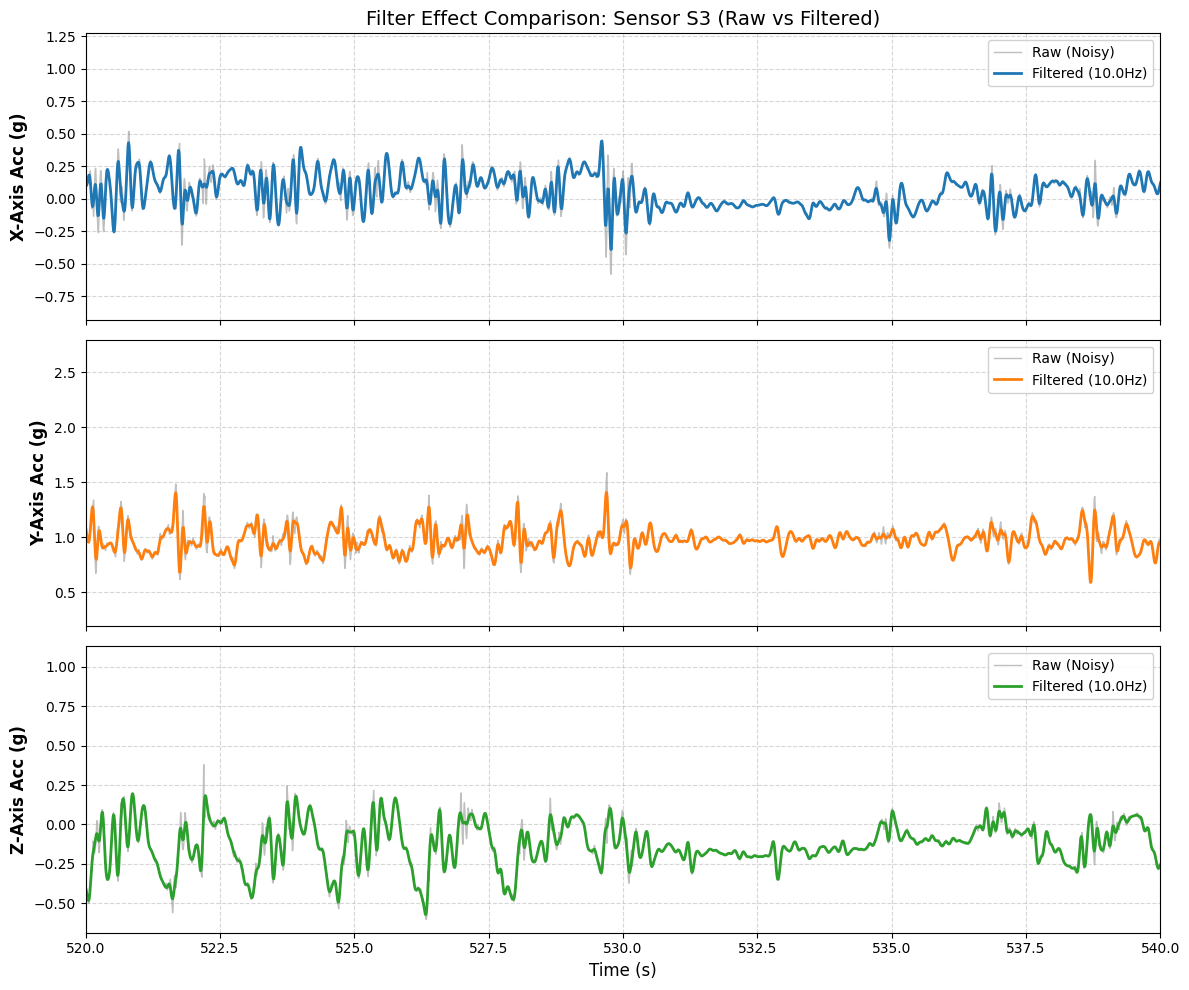

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- 1. 滤波器定义 ---
def butter_lowpass_filter(data, cutoff, fs, order=4):
    """
    使用零相位滤波 (filtfilt) 以防止波峰出现时间延迟
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

# --- 2. 数据读取与预处理 ---
file_path = '/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/Merged_6IMU_PerfectSync.csv'

try:
    df = pd.read_csv(file_path)
    
    # 填充缺失值 (线性插值)，防止滤波报错
    df_clean = df.interpolate(method='linear').ffill().bfill()
    
    # 自动计算采样率
    if 'elapsed (s)' in df_clean.columns:
        fs = 1 / df_clean['elapsed (s)'].diff().mean()
    else:
        fs = 100.0 # 默认值

    # --- 3. 参数设置 ---
    sensor_id = 'S3'      # 你可以选择 S1 - S6 (S2通常是腰部/骶骨，步态特征最明显)
    cutoff_freq = 10.0     # 截止频率 6Hz
    
    # 准备绘图
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    directions = ['x', 'y', 'z']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # 蓝、橙、绿
    
    print(f"正在处理传感器: {sensor_id}, 采样率: {fs:.1f}Hz, 截止频率: {cutoff_freq}Hz")

    # --- 4. 循环绘制三个轴 ---
    for i, ax_code in enumerate(directions):
        col_name = f'{sensor_id}_acc_{ax_code}'
        
        if col_name in df_clean.columns:
            # 获取数据
            t = df_clean['elapsed (s)']
            raw_data = df_clean[col_name].values
            
            # 执行滤波
            filtered_data = butter_lowpass_filter(raw_data, cutoff_freq, fs)
            
            # 绘图逻辑
            ax = axes[i]
            
            # A. 绘制原始数据 (灰色，半透明，作为背景)
            ax.plot(t, raw_data, color='gray', alpha=0.5, linewidth=1, label='Raw (Noisy)')
            
            # B. 绘制滤波数据 (彩色，加粗，作为前景)
            ax.plot(t, filtered_data, color=colors[i], linewidth=2, label=f'Filtered ({cutoff_freq}Hz)')
            
            # 装饰
            ax.set_ylabel(f'{ax_code.upper()}-Axis Acc (g)', fontsize=12, fontweight='bold')
            ax.legend(loc='upper right', frameon=True, framealpha=0.9)
            ax.grid(True, linestyle='--', alpha=0.5)
            
            # 仅在第一张图显示标题
            if i == 0:
                ax.set_title(f'Filter Effect Comparison: Sensor {sensor_id} (Raw vs Filtered)', fontsize=14)
                
        else:
            axes[i].text(0.5, 0.5, f'Data {col_name} not found', ha='center')

    # --- 5. 视图优化 ---
    axes[-1].set_xlabel('Time (s)', fontsize=12)
    
    # *** 关键步骤：自动缩放 ***
    # 全程数据太长，压缩在一起看不清滤波细节。
    # 这里自动选取中间的 10 秒钟进行放大展示。
    mid_time = df_clean['elapsed (s)'].iloc[len(df_clean)//2]
    window_size = 10 # 显示 10 秒窗口
    plt.xlim(520, 540)
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"发生错误: {e}")

/tmp/ipykernel_499238/826813800.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_interp = data.interpolate().fillna(method='bfill').fillna(method='ffill')


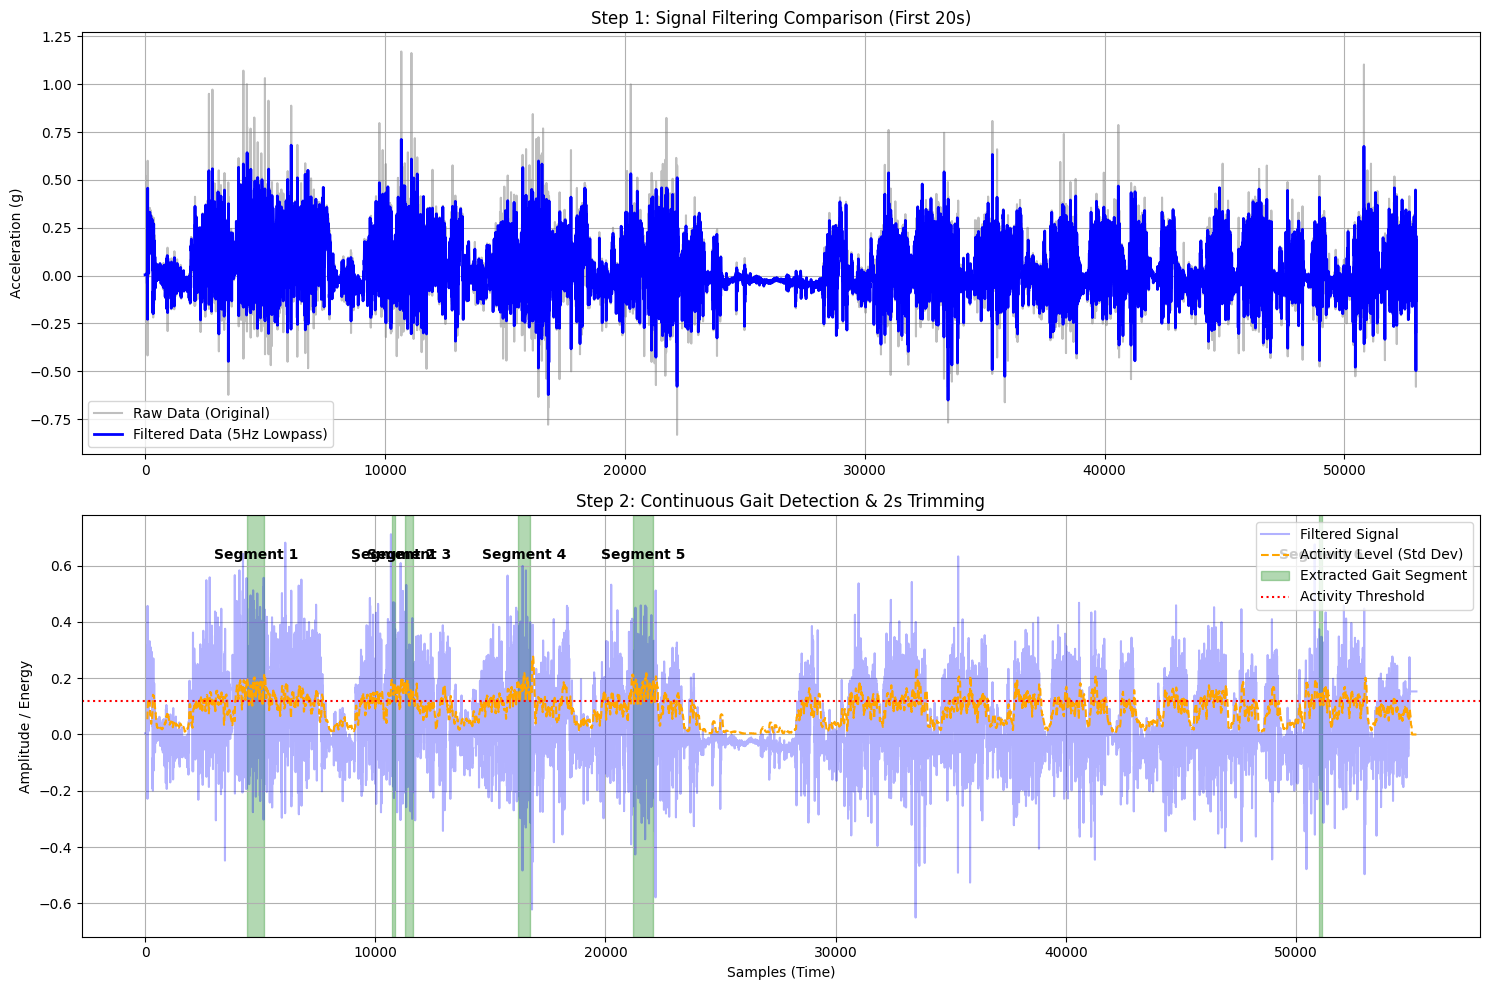

处理完成！共识别出 6 段连续步态数据。


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- 1. 配置与数据加载 ---
file_path = '/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/Merged_6IMU_PerfectSync.csv'
df = pd.read_csv(file_path)
fs = 100  # 采样频率 100Hz

# --- 2. 滤波器函数 ---
def butter_lowpass_filter(data, cutoff=10, fs=100, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    # 线性插值处理 NaN，确保滤波正常运行
    data_interp = data.interpolate().fillna(method='bfill').fillna(method='ffill')
    return filtfilt(b, a, data_interp)

# --- 3. 处理数据 ---
# 选择一个代表性通道进行演示（例如 S2 传感器的 Y 轴加速度）
target_col = 'S3_acc_x'
df['S2_acc_y_filtered'] = butter_lowpass_filter(df[target_col], cutoff=12, fs=fs)

# --- 4. 步态识别与裁剪逻辑 ---
def get_segments(df, col_name, threshold=0.1, trim_sec=2):
    # 计算滑动标准差作为“活跃度”指标
    activity_signal = df[col_name].rolling(window=fs).std()
    is_active = activity_signal > threshold
    
    segments = []
    start = None
    trim_size = trim_sec * fs
    
    for i in range(len(is_active)):
        if is_active.iloc[i] and start is None:
            start = i
        elif not is_active.iloc[i] and start is not None:
            duration = i - start
            # 只有当长度大于裁剪长度(前后各2秒)时才保留
            if duration > (2 * trim_size + fs): 
                segments.append((start + trim_size, i - trim_size))
            start = None
    return segments, activity_signal

segments, activity_sig = get_segments(df, 'S2_acc_y_filtered')

# --- 5. 可视化绘制 ---
plt.figure(figsize=(15, 10))

# 子图 1: 滤波效果对比
plt.subplot(2, 1, 1)
plt.plot(df[target_col].values[:53000], label='Raw Data (Original)', alpha=0.5, color='gray')
plt.plot(df['S2_acc_y_filtered'].values[:53000], label='Filtered Data (5Hz Lowpass)', color='blue', linewidth=2)
plt.title('Step 1: Signal Filtering Comparison (First 20s)')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.grid(True)

# 子图 2: 步态分拣与裁剪展示
plt.subplot(2, 1, 2)
plt.plot(df['S2_acc_y_filtered'].values, label='Filtered Signal', color='blue', alpha=0.3)
plt.plot(activity_sig.values, label='Activity Level (Std Dev)', color='orange', linestyle='--')

# 标记分拣出的连续步态区间
for i, (s, e) in enumerate(segments):
    plt.axvspan(s, e, color='green', alpha=0.3, label='Extracted Gait Segment' if i == 0 else "")
    plt.text((s+e)//2, plt.ylim()[1]*0.8, f'Segment {i+1}', ha='center', weight='bold')

plt.axhline(y=0.12, color='red', linestyle=':', label='Activity Threshold')
plt.title('Step 2: Continuous Gait Detection & 2s Trimming')
plt.xlabel('Samples (Time)')
plt.ylabel('Amplitude / Energy')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"处理完成！共识别出 {len(segments)} 段连续步态数据。")

# SHRED model function

In [17]:
### Generate input sequences to a SHRED model
def train_SHRED_model(transformed_X, sc, train_indices, valid_indices, test_indices, sensor_locations, num_sensors, m, n, lags):
  """
    Trains SHRED model for time series reconstruction

  Args: 
    transformed_X (numpy array): MinMax scaled dataset.
    sc (MinMaxScaler): Fitted MinMax scaler for inverse transformation.
    train_indices (array): Indices for the training set.
    valid_indices (array): Indices for the validation set.
    test_indices (array): Indices for the test set.
    sensor_locations (array): Column indices for sensor data.
    num_sensors (int): Number of signal measurements from sensors (e.g, triaxial = 3)
    m (int): Number of features per timestep
    n (int): Total number of time steps (observations)
    lags (int): length of trajectory
    
  Return:
    test_recons: Reconstructed data from the SHRED model on the test set
    test_ground_truth: Ground truth data from the test set
  """

  all_data_in = np.zeros((n - lags, lags, num_sensors))
  for i in range(len(all_data_in)):
      all_data_in[i] = transformed_X[i:i+lags, sensor_locations]
  ### Generate training validation and test datasets both for reconstruction of states and forecasting sensors
  device = 'cuda' if torch.cuda.is_available() else 'cpu'

  train_data_in = torch.tensor(all_data_in[train_indices], dtype=torch.float32).to(device)
  valid_data_in = torch.tensor(all_data_in[valid_indices], dtype=torch.float32).to(device)
  test_data_in = torch.tensor(all_data_in[test_indices], dtype=torch.float32).to(device)

  ### -1 to have output be at the same time as final sensor measurements
  train_data_out = torch.tensor(transformed_X[train_indices + lags - 1], dtype=torch.float32).to(device)
  valid_data_out = torch.tensor(transformed_X[valid_indices + lags - 1], dtype=torch.float32).to(device)
  test_data_out = torch.tensor(transformed_X[test_indices + lags - 1], dtype=torch.float32).to(device)

  train_dataset = TimeSeriesDataset(train_data_in, train_data_out)
  valid_dataset = TimeSeriesDataset(valid_data_in, valid_data_out)
  test_dataset = TimeSeriesDataset(test_data_in, test_data_out)


  ##Modify this part for TCN
  #shred = models_TCN.SHRED_TCN(num_sensors, m, number_channels=2, hidden_layers=2, l1=350, l2=400, dropout=0.1).to(device)
  tcn_chaneels = [64, 64]
  shred = models_TCN.SHRED_TCN(num_sensors, m, num_channels=tcn_chaneels, fc_layers=[350, 400], kernel_size=3, dropout=0.1).to(device)

  validation_errors = models_TCN.fit(shred, train_dataset, valid_dataset, batch_size=64, num_epochs=500, lr=1e-3, verbose=True, patience=3)

  # Generate reconstructions from the test set and print mean square error compared to the ground truth
  test_recons = sc.inverse_transform(shred(test_dataset.X).detach().cpu().numpy())
  test_ground_truth = sc.inverse_transform(test_dataset.Y.detach().cpu().numpy())

  return test_recons, test_ground_truth

# Train models

Divide the data into training, validation and test.

In [18]:
# partition into training, validation, test sets
train_indices, valid_indices, test_indices = ft.partition_data_seq(load_X, n, lags) 

# normalize input data using MinMaxScaler
transformed_X, sc = ft.transform_data(load_X, train_indices) 

### Define input sensor

In [19]:
# choose input sensor location
sensor_place = 'RightAnkle' # RightAnkle, Waist, or Chest

# choose input sensor type
sensor_path = '3acc3gyro_Training' # 3acc_Training, 3gyro_Training, 3acc3gyro_Training, or Xacc_Training

# access columns indices from main dataframe
sensor_locations, num_sensors = ft.sensor_loc_fun(sensor_path, sensor_place, df_2_data) # This function is specific to the dataset used in this project. Update it according the the types of signals (joint angles, EMG, etc) in your dataset.
train_names = [df_2_data.columns[i] for i in sensor_locations]

print('Number of signals: ', num_sensors)
print('Signals were chosen at: ', sensor_place)
print('Signals chosen: ', [df_2_data.columns[i] for i in sensor_locations])

Number of signals:  6
Signals were chosen at:  RightAnkle
Signals chosen:  ['RightAnkle_Acceleration_x', 'RightAnkle_Acceleration_y', 'RightAnkle_Acceleration_z', 'RightAnkle_AngularVelocity_x', 'RightAnkle_AngularVelocity_y', 'RightAnkle_AngularVelocity_z']


In [20]:
# check path for saving dataframes
if trial_length == 6 and frequency == 128: # full-length trial, full frequency
  save_train_df = dataframe_path+'/'+AC_path+'/'+sensor_place+'/'+sensor_path+'/P'+subj+'_Ytest_SHRED_Train_'+sensor_place+'_'+sensor_path+'.csv'
  save_test_df = dataframe_path+'/'+AC_path+'/'+sensor_place+'/'+sensor_path+'/P'+subj+'_Ypred_SHRED_Train_'+sensor_place+'_'+sensor_path+'.csv'
else: # reduced trial length or frequency
  save_train_df = dataframe_path+'/'+AC_path+'/'+sensor_place+'/'+sensor_path+'/P'+subj+'_Ypred_SHRED_Train_'+sensor_place+'_'+sensor_path+'_'+save_tag+'.csv'
  save_test_df = dataframe_path+'/'+AC_path+'/'+sensor_place+'/'+sensor_path+'/P'+subj+'_Ypred_SHRED_Train_'+sensor_place+'_'+sensor_path+'_'+save_tag+'.csv'

print(os.path.isdir(save_test_df))
print(save_train_df)
print(save_test_df)

False
/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Datasets/Dataframes/AC14/RightAnkle/3acc3gyro_Training/P01_Ypred_SHRED_Train_RightAnkle_3acc3gyro_Training_5min.csv
/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Datasets/Dataframes/AC14/RightAnkle/3acc3gyro_Training/P01_Ypred_SHRED_Train_RightAnkle_3acc3gyro_Training_5min.csv


In [21]:
test_indices

array([30657, 30658, 30659, ..., 38269, 38270, 38271], shape=(7615,))

In [22]:
# train SHRED model
Ypred, Ytest = train_SHRED_model(transformed_X, sc, train_indices, valid_indices, test_indices, sensor_locations, num_sensors, m, n, lags)

df_Ytest_SHRED = pd.DataFrame(Ytest, columns = df_2_data.columns)
df_Ypred_SHRED = pd.DataFrame(Ypred, columns = df_2_data.columns)

df_Ytest_SHRED['Type']='Measured'
df_Ypred_SHRED['Type']='SHRED'

df_Ytest_SHRED['Time']=df_2.iloc[test_indices + lags - 1,0].to_numpy()
df_Ypred_SHRED['Time']=df_2.iloc[test_indices + lags - 1,0].to_numpy()

# save dataframes as .csv if specified
#if save_df == True:
#  df_Ytest_SHRED.to_csv(save_train_df)
#  df_Ypred_SHRED.to_csv(save_test_df)


/mnt/ssd1/wyc/SHREDwyc/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Training epoch 1
Error tensor(0.1186, device='cuda:0')
Training epoch 20
Error tensor(0.0763, device='cuda:0')
Training epoch 40
Error tensor(0.0742, device='cuda:0')
Training epoch 60
Error tensor(0.0730, device='cuda:0')
Training epoch 80
Error tensor(0.0732, device='cuda:0')
Training epoch 100
Error tensor(0.0724, device='cuda:0')
Training epoch 120
Error tensor(0.0724, device='cuda:0')
Training epoch 140
Error tensor(0.0722, device='cuda:0')
Training epoch 160
Error tensor(0.0734, device='cuda:0')
Training epoch 180
Error tensor(0.0726, device='cuda:0')
Training epoch 200
Error tensor(0.0721, device='cuda:0')
Training epoch 220
Error tensor(0.0730, device='cuda:0')
Training epoch 240
Error tensor(0.0729, device='cuda:0')
Training epoch 260
Error tensor(0.0733, device='cuda:0')


# Visualize Results

In [23]:
df_SHRED_tidy = ft.concatRaw(1,sensor_place, sensor_path, 1, 1, df_Ypred_SHRED, df_Ytest_SHRED ,subj)

In [24]:
print("df_SHRED_tidy 的列名:", df_SHRED_tidy.columns)
print("df_SHRED_tidy 的头部数据:\n", df_SHRED_tidy.head(100))

df_SHRED_tidy 的列名: Index(['Subject', 'Pred', 'True', 'Input Location', 'Sensor Type',
       'Output Location', 'Output Signal', 'Output Direction', 'Output Axis',
       'Assessment', 'Time'],
      dtype='object')
df_SHRED_tidy 的头部数据:
    Subject       Pred       True Input Location  \
0       01 -16.071655 -16.952082     RightAnkle   
1       01  -0.496503  -0.159575     RightAnkle   
2       01   1.440551   1.466084     RightAnkle   
3       01   1.526632   1.508507     RightAnkle   
4       01   0.003644  -0.012126     RightAnkle   
..     ...        ...        ...            ...   
95      01   5.615416   5.429745     RightAnkle   
96      01  15.716375  14.881917     RightAnkle   
97      01  35.071835  36.683228     RightAnkle   
98      01  -7.195542  -6.672711     RightAnkle   
99      01 -17.028294    -17.907     RightAnkle   

                           Sensor Type Output Location     Output Signal  \
0   Triaxial Accelerometer & Gyroscope           Waist      Acceleration 

In [25]:
# format: ft.extractSignal(output_location, output_signal, output_axis, df_SHRED_tidy)
    # output_location: 'Chest', 'Waist', 'RightAnkle', 'LeftAnkle'
    # output_signal: 'Acceleration', 'Angular Velocity', 'Magnetic Field'
    # output_axis: 'x', 'y', z'

Signal1 = ft.extractSignal('LeftAnkle', 'Acceleration', 'x', df_SHRED_tidy)
Signal2 = ft.extractSignal('Chest', 'Acceleration', 'x', df_SHRED_tidy)
Signal3 = ft.extractSignal('Waist', 'Acceleration', 'x', df_SHRED_tidy)

my_scheme = ['#1e88e5', "#6E6E6E"] # '#014337', '#1e88e5', '#DB1048'

# Compute error: ft.rmse_error, ft.mae_error, OR ft.mbe_error
Signal1_error = ft.rmse_error(Signal1[Signal1['Type'] == 'True']['Value'], Signal1[Signal1['Type'] == 'SHRED']['Value'])
Signal2_error = ft.rmse_error(Signal2[Signal2['Type'] == 'True']['Value'], Signal2[Signal2['Type'] == 'SHRED']['Value'])
Signal3_error = ft.rmse_error(Signal3[Signal3['Type'] == 'True']['Value'], Signal3[Signal3['Type'] == 'SHRED']['Value'])

# plot left ankle acceleration
line1 = alt.Chart(Signal1).mark_line().encode(
    x=alt.X('Time:Q', title='Time (s)'),
    y=alt.Y('Value:Q', title='Acceleration (m/s\u00b2)'),
    color=alt.Color('Type:N', scale=alt.Scale(range=my_scheme))
).properties(
    width=600,
    height=400,
    title=f'Signal 1 LightAnkle: RMSE = {Signal1_error:.2f}'  # Can change this title to be specific to the output signal
)
# plot chest acceleration
line2 = alt.Chart(Signal2).mark_line().encode(
    x=alt.X('Time:Q', title='Time (s)'),
    y=alt.Y('Value:Q', title='Acceleration (m/s\u00b2)'),
    color=alt.Color('Type:N', scale=alt.Scale(range=my_scheme))
).properties(
    width=600,
    height=400,
    title=f'Signal 2: Chest RMSE = {Signal2_error:.2f}'  # Can change this title to be specific to the output signal
)

# plot Waist acceleration
line3 = alt.Chart(Signal3).mark_line().encode(
    x=alt.X('Time:Q', title='Time (s)'),
    y=alt.Y('Value:Q', title='Acceleration (m/s\u00b2)'),
    color=alt.Color('Type:N', scale=alt.Scale(range=my_scheme))
).properties(
    width=600,
    height=400,
    title=f'Signal 3: Waist RMSE = {Signal3_error:.2f}'  # Can change this title to be specific to the output signal
)

final_chart = alt.vconcat(line1, line2, line3).properties(
    title=f'Parameter = {save_tag}, Right Ankle Input' # Can change this title to match the input sensor
    # increase font size
).configure_axis(
    labelFontSize=18,
    titleFontSize=20
).configure_title(
    fontSize=24
).configure_legend(
    labelFontSize=18,
    titleFontSize=20
)

final_chart

alt.VConcatChart(...)